# 6.5 Machine Learning Part 2
## Table of Contents
1. Imports/Pathways
2. Data Inspection
3. Elbow Technique
4. K-Means Clustering
5. Plotting k-means Clustering
    - Aftertaste vs Total Cup Points
    - Flavor vs Total Cup Points
    - Acidity vs Total Cup Points
6. Cluster Comparison: k = 3 vs k = 4
7. Merge Cluster Labels into Full Dataset

## 1. Imports/Pathways

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import os

# Visualization:
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# File Pathway
path = r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee"

In [5]:
# Import Main dataset
df_coffee_m = pd.read_excel(r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\02_Data\Prepared_Data\Coffee_Datasets_Merged.xlsx')

## 2. Data Inspection

In [6]:
df_coffee_m.shape

(8877, 35)

In [7]:
df_coffee_m.head()

,coffee_name,total_score,roast_level,agtron_roast,price_usd,quantity_g,usd_per_gram,roaster_location,roaster_city,roaster_region,...,body,balance,uniformity,clean_cup,sweetness,cupper_points,total_cup_points,moisture,unit_of_measurement,altitude_mean_meters
0,colombia finca campo hermosa,94,light,82,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.58,7.58,10.0,10.0,10.0,7.58,83.17,0.11,m,NaN
1,colombia finca campo hermosa,94,light,82,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.75,7.50,10.0,10.0,10.0,7.50,83.00,0.00,m,NaN
2,colombia finca campo hermosa,94,light,82,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.67,7.83,10.0,10.0,10.0,7.58,82.67,0.21,m,NaN
3,colombia finca campo hermosa,94,light,82,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.67,7.42,10.0,10.0,10.0,7.25,82.08,0.11,m,NaN
4,colombia finca campo hermosa,94,light,82,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.08,7.42,10.0,10.0,10.0,7.25,80.67,0.18,m,NaN


In [8]:
df_coffee_m.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
total_score,8877.0,94.52,0.72,94.00,94.00,94.00,95.00,98.00
harvest_year,5020.0,2013.63,1.37,2010.00,2013.00,2014.00,2014.00,2017.00
aroma,7342.0,7.68,0.29,6.50,7.50,7.67,7.83,8.58
flavor,7342.0,7.65,0.33,6.17,7.42,7.67,7.75,8.67
aftertaste,7342.0,7.57,0.36,6.17,7.42,7.58,7.75,8.50
acidity,7342.0,7.63,0.36,6.50,7.42,7.58,7.83,8.50
body,7342.0,7.66,0.29,6.50,7.50,7.67,7.83,8.50
balance,7342.0,7.71,0.29,6.17,7.58,7.67,7.83,8.58
uniformity,7342.0,9.86,0.54,6.67,10.00,10.00,10.00,10.00
clean_cup,7342.0,9.90,0.50,5.33,10.00,10.00,10.00,10.00


This will help with cluster ranges later

In [9]:
# Drop non-numeric columns
features_for_clustering = [
    'aroma', 'flavor', 'aftertaste', 'acidity', 'body', 'balance',
    'uniformity', 'clean_cup', 'sweetness', 'cupper_points',
    'total_cup_points', 'moisture'
]

In [10]:
# Calculate missing counts and percentages
missing_counts = df_coffee_m[features_for_clustering].isnull().sum()
missing_percent = (missing_counts / len(df_coffee_m)) * 100

In [11]:
# Optional: drop rows with missing values in selected features
df_cluster = df_coffee_m[features_for_clustering].dropna()

# Combine into a single DataFrame for previewing
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent.round(2)
}).sort_values(by='Missing Count', ascending=False)

missing_summary

,Missing Count,Missing %
aroma,1535,17.29
flavor,1535,17.29
aftertaste,1535,17.29
acidity,1535,17.29
body,1535,17.29
balance,1535,17.29
uniformity,1535,17.29
clean_cup,1535,17.29
sweetness,1535,17.29
cupper_points,1535,17.29


In [12]:
# Drop rows with missing data
df_cluster = df_coffee_m[features_for_clustering].dropna()

##### Missing Value Audit for Clustering Features
All 12 sensory and quality-related features show identical missingness: 1,535 rows (17.29%). This suggests a subset of entries lacks full sensory evaluation. For clustering, these rows were excluded to ensure consistent input dimensions and avoid bias from imputation. The original dataset remains untouched for future analysis.


## 3. Elbow Technique

In [13]:
# Standardize the data for clustering later.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

In [14]:
# Do the elbow method to find optimal k
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

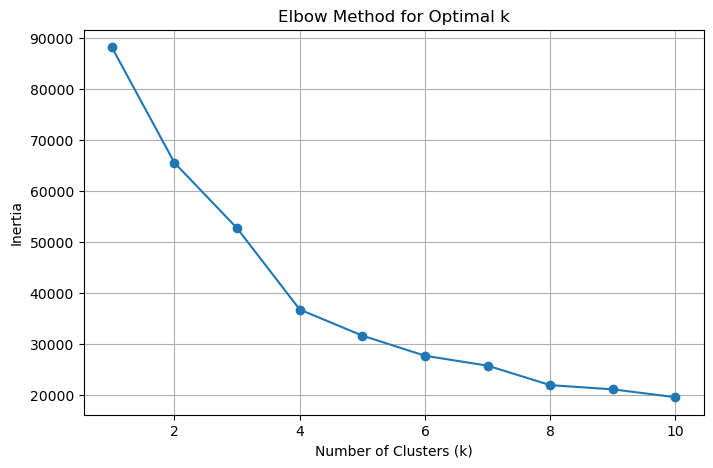

In [15]:
# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

##### Elbow Method Interpretation
The inertia curve shows a steep decline from k = 1 to k = 3, followed by a more gradual decrease. This suggests that the optimal number of clusters lies around k = 3 or k = 4. I selected to test both 3 and 4.

## 4. K-Means Clustering

In [16]:
# Fit Both Models, create two columns cluster_3 and cluster_4
# k = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42)
df_cluster['cluster_3'] = kmeans_3.fit_predict(scaled_data)

# k = 4
kmeans_4 = KMeans(n_clusters=4, random_state=42)
df_cluster['cluster_4'] = kmeans_4.fit_predict(scaled_data)

In [17]:
# summary for k = 3
df_cluster.groupby('cluster_3').mean().round(2)

,aroma,flavor,aftertaste,acidity,body,balance,uniformity,clean_cup,sweetness,cupper_points,total_cup_points,moisture,cluster_4
cluster_3,,,,,,,,,,,,,
0,7.31,7.29,7.16,7.31,7.46,7.41,9.07,9.22,9.25,7.27,78.74,0.08,0.60
1,7.69,7.63,7.55,7.59,7.63,7.70,9.98,10.00,9.99,7.65,83.41,0.08,0.74
2,8.10,8.31,8.19,8.28,8.13,8.19,9.97,10.00,9.87,8.47,87.52,0.08,1.80


In [18]:
# summary for k = 4
df_cluster.groupby('cluster_4').mean().round(2)

,aroma,flavor,aftertaste,acidity,body,balance,uniformity,clean_cup,sweetness,cupper_points,total_cup_points,moisture,cluster_3
cluster_4,,,,,,,,,,,,,
0,7.41,7.33,7.22,7.32,7.42,7.50,9.91,9.95,9.96,7.40,81.41,0.10,0.69
1,7.74,7.72,7.63,7.69,7.71,7.74,9.92,9.96,9.94,7.71,83.76,0.07,1.00
2,8.15,8.37,8.26,8.32,8.18,8.25,9.97,10.00,9.84,8.59,87.92,0.08,2.00
3,7.96,7.31,7.70,7.32,7.41,7.63,6.72,6.68,6.74,7.30,72.77,0.00,0.00


In [19]:
# Get mean values per cluster
cluster_means = df_cluster.groupby('cluster_3')[features_for_clustering].mean()

# Calculate range (max - min) across clusters for each feature
feature_spread = cluster_means.max() - cluster_means.min()
feature_spread.sort_values(ascending=False)

total_cup_points    8.779633
cupper_points       1.201849
aftertaste          1.036274
flavor              1.023300
acidity             0.972207
uniformity          0.917114
aroma               0.783611
balance             0.781978
clean_cup           0.775120
sweetness           0.734419
body                0.677600
moisture            0.001468
dtype: float64

I wanted to test out the top 3 variables against total_cup_points which are aftertaste, flavor, and acidity. Note cupper_points would be redundant to use. 

## 5. Plotting k-means Clustering

### Aftertaste & Total cup Points

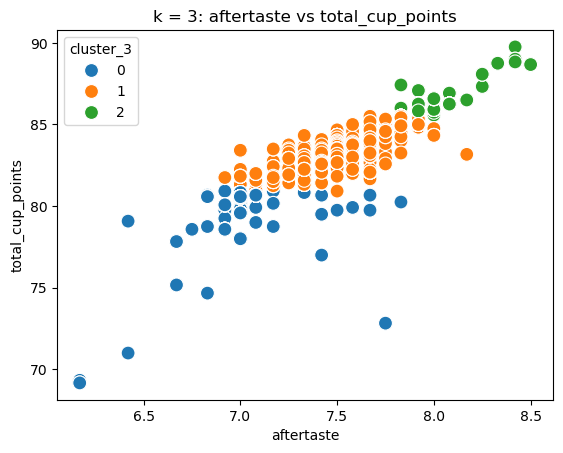

In [18]:
# k = 3
sns.scatterplot(data=df_cluster, x='aftertaste', y='total_cup_points', hue='cluster_3', palette='tab10', s=100)
plt.title('k = 3: aftertaste vs total_cup_points')
plt.savefig(r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\k-means clustering comparison\aftertaste_vs_totalcup_k3.png', bbox_inches='tight')
plt.show()


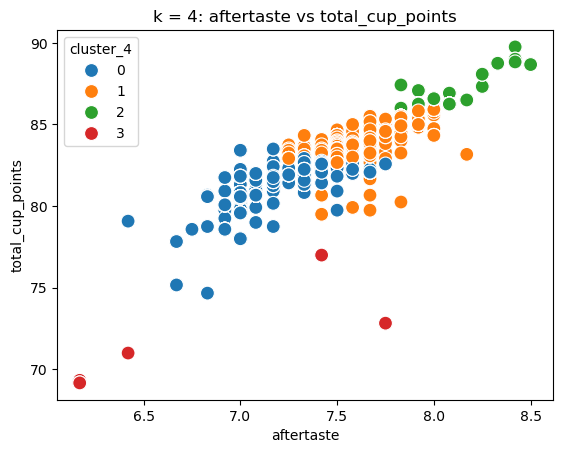

In [33]:
# k = 4
sns.scatterplot(data=df_cluster, x='aftertaste', y='total_cup_points', hue='cluster_4', palette='tab10', s=100)
plt.title('k = 4: aftertaste vs total_cup_points')
plt.savefig(r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\k-means clustering comparison\aftertaste_vs_totalcup_k4.png', bbox_inches='tight')
plt.show()

##### Aftertaste vs Total Cup Points
- k = 3: Shows strong vertical separation. One cluster dominates the high aftertaste/high cup score region, suggesting clear quality tiers.
- k = 4: Adds a fourth group that overlaps slightly, offering more granularity but less visual clarity.

### Flavor & Total cup Points

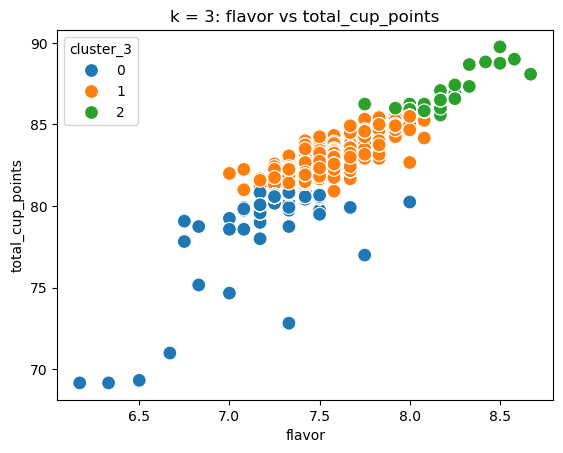

In [19]:
# k = 3
sns.scatterplot(data=df_cluster, x='flavor', y='total_cup_points', hue='cluster_3', palette='tab10', s=100)
plt.title('k = 3: flavor vs total_cup_points')
plt.savefig(r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\k-means clustering comparison\flavor_vs_totalcup_k3.png', bbox_inches='tight')
plt.show()

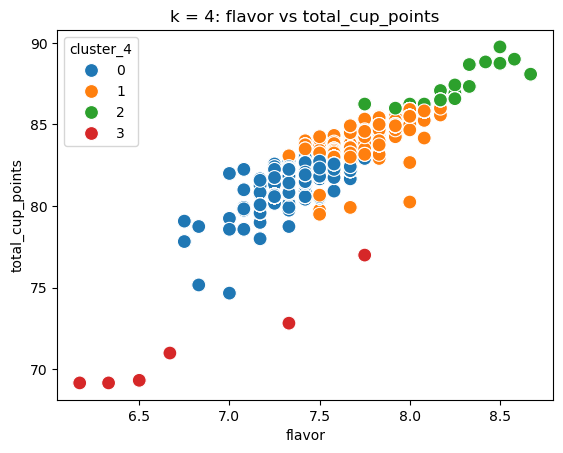

In [42]:
# k = 4
sns.scatterplot(data=df_cluster, x='flavor', y='total_cup_points', hue='cluster_4', palette='tab10', s=100)
plt.title('k = 4: flavor vs total_cup_points')
plt.savefig(r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\k-means clustering comparison\flavor_vs_totalcup_k4.png', bbox_inches='tight')
plt.show()


##### Flavor vs Total Cup Points
- k = 3: Displays a clean positive correlation, with one cluster consistently scoring higher in both flavor and total cup points.
- k = 4: Splits the middle zone, introducing nuance but also some overlap that may dilute interpretability.


### Acidity & Total cup Points

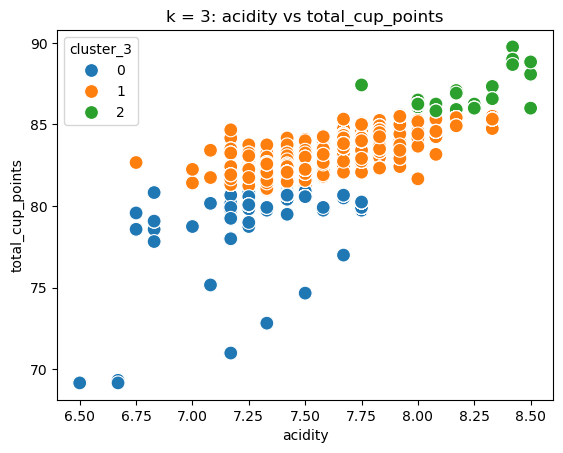

In [20]:
# k = 3
sns.scatterplot(data=df_cluster, x='acidity', y='total_cup_points', hue='cluster_3', palette='tab10', s=100)
plt.title('k = 3: acidity vs total_cup_points')
plt.savefig(r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\k-means clustering comparison\acidity_vs_totalcup_k3.png', bbox_inches='tight')
plt.show()

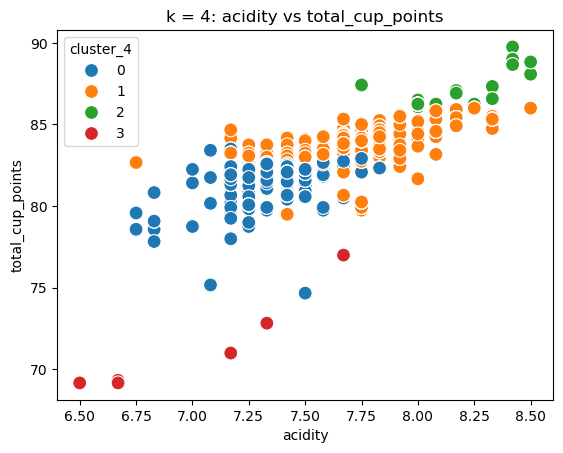

In [37]:
# k = 4
sns.scatterplot(data=df_cluster, x='acidity', y='total_cup_points', hue='cluster_4', palette='tab10', s=100)
plt.title('k = 4: acidity vs total_cup_points')
plt.savefig(r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\04_Analysis\Visulazations\k-means clustering comparison\acidity_vs_totalcup_k4.png', bbox_inches='tight')
plt.show()


##### Acidity vs Total Cup Points
- k = 3: Offers distinct vertical separation, with clusters clearly stratified by acidity and cup score.
- k = 4: Adds a fourth group that overlaps with others, making the boundaries less intuitive

## 6. Cluster Comparison: k = 3 vs k = 4

To evaluate natural groupings in coffee quality, I ran k-means clustering with both k = 3 and k = 4. I visualized each setup across three key sensory features — aftertaste, flavor, and acidity — against total cup points.

- k = 3 produced clean, visually distinct clusters that aligned with intuitive quality tiers.
- k = 4 introduced more granularity but also more overlap, making interpretation less straightforward.

After reviewing all plots, I selected k = 3 for its clarity, interpretability, and storytelling value. This configuration supports a teachable, audit-ready analysis of coffee quality segmentation.

In [20]:
# Create a new column for tier labels based on cluster_3
df_cluster['cluster_3_tier'] = df_cluster['cluster_3']

# Replace numeric cluster labels with descriptive tier names
df_cluster.loc[df_cluster['cluster_3'] == 0, 'cluster_3_tier'] = 'Low Coffee'
df_cluster.loc[df_cluster['cluster_3'] == 1, 'cluster_3_tier'] = 'Mid Coffee'
df_cluster.loc[df_cluster['cluster_3'] == 2, 'cluster_3_tier'] = 'Top Coffee'


C:\Users\Chase\AppData\Local\Temp\ipykernel_25356\3691436006.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Low Coffee' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df_cluster.loc[df_cluster['cluster_3'] == 0, 'cluster_3_tier'] = 'Low Coffee'


In [21]:
# Group by tier label and summarize key features
df_cluster.groupby('cluster_3_tier').agg({
    'flavor': ['mean', 'median'],
    'aftertaste': ['mean', 'median'],
    'acidity': ['mean', 'median'],
    'total_cup_points': ['mean', 'median']
})

flavor        aftertaste          acidity         \
                    mean median       mean median      mean median   
cluster_3_tier                                                       
Low Coffee      7.287749   7.25   7.157435   7.00  7.305466   7.33   
Mid Coffee      7.625556   7.67   7.550724   7.58  7.593825   7.58   
Top Coffee      8.311049   8.33   8.193708   8.25  8.277673   8.42   

               total_cup_points         
                           mean median  
cluster_3_tier                          
Low Coffee            78.736262  79.92  
Mid Coffee            83.406187  83.33  
Top Coffee            87.515895  88.08

### Clustering Results

This clustering setup lays the groundwork for multiple downstream uses. By segmenting coffee samples based on sensory scores and total cup points, we now have a reproducible way to group coffees into quality tiers without relying on subjective thresholds. This could be used to support:
- Quality control: flagging underperforming coffee samples for review or exclusion
- Pricing strategy: match up high-scoring clusters with premium prices
- Sourcing decisions: identifying which regions or producers consistently land in top-tier clusters
- Stakeholder storytelling: using visual and statistical evidence to explain quality segmentation clearly


## 7. Merge Cluster Labels into Full Dataset

In [22]:
# Copy original rows that were clustered (same index as df_cluster)
df_clustered_full = df_coffee_m.loc[df_cluster.index].copy()

# Attach cluster labels and tier names
df_clustered_full['cluster_3'] = df_cluster['cluster_3']
df_clustered_full['cluster_3_tier'] = df_cluster['cluster_3_tier']

# Work Check
print(df_clustered_full[['coffee_name', 'roast_level', 'flavor', 'total_cup_points', 'cluster_3', 'cluster_3_tier']].head())

# Export with cluster columns added
df_clustered_full.to_csv(
    r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\02_Data\Prepared_Data\coffee_merge_cluster.csv',
    index=False
)

                    coffee_name roast_level  flavor  total_cup_points  \
0  colombia finca campo hermosa       light    7.75             83.17   
1  colombia finca campo hermosa       light    7.58             83.00   
2  colombia finca campo hermosa       light    7.42             82.67   
3  colombia finca campo hermosa       light    7.42             82.08   
4  colombia finca campo hermosa       light    7.25             80.67   

   cluster_3 cluster_3_tier  
0          1     Mid Coffee  
1          1     Mid Coffee  
2          1     Mid Coffee  
3          1     Mid Coffee  
4          0     Low Coffee  


## Export

In [24]:
# Export clustered subset with k = 3 results to Prepared_Data folder
df_cluster_export = df_cluster[['aroma', 'flavor', 'aftertaste', 'acidity', 'body', 'balance',
                                'uniformity', 'clean_cup', 'sweetness', 'cupper_points',
                                'total_cup_points', 'moisture', 'cluster_3', 'cluster_3_color']]

df_cluster_export.to_excel(
    r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\02_Data\Prepared_Data\coffee_clustered_k3.xlsx',
    index=False
)